# Import required libraries
import mlx.core as mx
import mlx.nn as nn
import mlx.optimizers as optim
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Optional, Tuple
import time

# Import RLVR modules
from rlvr_core import (
    RLVRRewardComputer, 
    SQLVerifier, 
    CodeVerifier,
    PatternVerifier,
    VerificationResult
)
from rlvr_training import PPOConfig, PPOTrainer, RLVRScheduler
from rlvr_data import (
    RLVRDataGenerator, 
    ExperienceBuffer, 
    CurriculumScheduler,
    Trajectory
)
from rlvr_lora_integration import (
    RLVRLoRAConfig,
    RLVRLoRAModel,
    HybridRLVRTrainer,
    create_rlvr_lora_model,
    run_rlvr_lora_training
)
from training_utils import (
    RLVRMetricsTracker,
    RLVRPlateauHandler,
    create_rlvr_scheduler,
    analyze_rlvr_training
)

# Import the base LoRA model
from lora_models import SimpleLoRATransformer, LoRALinear

print("RLVR Training Pipeline initialized!")
print(f"MLX version: {mx.__version__}")
print(f"Running on: {mx.default_device()}")

# Set seed for reproducibility
mx.random.seed(42)
np.random.seed(42)

## 1. Setup and Imports

In [1]:
# Import required libraries
import mlx.core as mx
import mlx.nn as nn
import mlx.optimizers as optim
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Optional, Tuple
import time

# Import RLVR modules
from rlvr_core import (
    RLVRRewardComputer, 
    SQLVerifier, 
    CodeVerifier,
    PatternVerifier,
    VerificationResult
)
from rlvr_training import PPOConfig, PPOTrainer, RLVRScheduler
from rlvr_data import (
    RLVRDataGenerator, 
    ExperienceBuffer, 
    CurriculumScheduler,
    Trajectory
)
from rlvr_lora_integration import (
    RLVRLoRAConfig,
    RLVRLoRAModel,
    HybridRLVRTrainer,
    create_rlvr_lora_model,
    run_rlvr_lora_training
)
from training_utils import (
    RLVRMetricsTracker,
    RLVRPlateauHandler,
    create_rlvr_scheduler,
    analyze_rlvr_training
)

# Import the base LoRA model
from lora_models import SimpleLoRATransformer, LoRALinear

print("RLVR Training Pipeline initialized!")
print(f"MLX version: {mx.__version__}")
print(f"Running on: {mx.default_device()}")

# Set seed for reproducibility
mx.random.seed(42)
np.random.seed(42)

RLVR Training Pipeline initialized!
MLX version: 0.27.1
Running on: Device(gpu, 0)


## 2. Initialize Base Model with LoRA

In [2]:
# Create base transformer model with LoRA adapters
vocab_size = 5000  # Increased for better token coverage
base_model = SimpleLoRATransformer(
    vocab_size=vocab_size,
    d_model=256,
    num_heads=8,
    num_layers=6,
    d_ff=1024,
    max_seq_len=512,
    lora_rank=16,  # Higher rank for RLVR
    lora_alpha=32.0
)

# Count parameters
def count_parameters(model):
    total = 0
    trainable = 0
    
    if hasattr(model, 'named_parameters'):
        for name, param in model.named_parameters():
            param_count = param.size
            total += param_count
            
            # Count as trainable if it's LoRA, embedding, or norm parameter
            if any(keyword in name for keyword in ['lora_A', 'lora_B', 'embedding', 'norm']):
                trainable += param_count
                print(f"  Trainable: {name} - {param.shape}")
    else:
        # Fallback for MLX modules
        total = sum(p.size for p in model.parameters())
        trainable = total  # Assume all are trainable for now
    
    return total, trainable

total_params, trainable_params = count_parameters(base_model)
print(f"\nModel Statistics:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable (LoRA) parameters: {trainable_params:,}")
print(f"  Parameter efficiency: {trainable_params/total_params*100:.2f}% trainable")

  Trainable: token_embedding.weight - (5000, 256)
  Trainable: position_embedding.weight - (512, 256)
  Trainable: blocks.0.attention.q_proj.lora_A - (256, 16)
  Trainable: blocks.0.attention.q_proj.lora_B - (16, 256)
  Trainable: blocks.0.attention.k_proj.lora_A - (256, 16)
  Trainable: blocks.0.attention.k_proj.lora_B - (16, 256)
  Trainable: blocks.0.attention.v_proj.lora_A - (256, 16)
  Trainable: blocks.0.attention.v_proj.lora_B - (16, 256)
  Trainable: blocks.0.attention.o_proj.lora_A - (256, 16)
  Trainable: blocks.0.attention.o_proj.lora_B - (16, 256)
  Trainable: blocks.0.feed_forward.linear1.lora_A - (256, 16)
  Trainable: blocks.0.feed_forward.linear1.lora_B - (16, 1024)
  Trainable: blocks.0.feed_forward.linear2.lora_A - (1024, 16)
  Trainable: blocks.0.feed_forward.linear2.lora_B - (16, 256)
  Trainable: blocks.0.norm1.weight - (256,)
  Trainable: blocks.0.norm1.bias - (256,)
  Trainable: blocks.0.norm2.weight - (256,)
  Trainable: blocks.0.norm2.bias - (256,)
  Trainable:

## 3. Configure RLVR Training

In [3]:
# Create RLVR-LoRA configuration
rlvr_config = RLVRLoRAConfig(
    # LoRA parameters
    lora_rank=16,
    lora_alpha=32.0,
    lora_dropout=0.05,
    
    # Training phases
    sft_steps=500,  # Initial supervised fine-tuning
    rlvr_steps=2000,  # RLVR training
    hybrid_mode=True,  # Alternate between SFT and RLVR
    hybrid_ratio=0.2,  # 20% SFT, 80% RLVR
    
    # Learning rates
    sft_lr=5e-4,
    rlvr_lr=1e-4,
    
    # Other settings
    use_curriculum=True,
    save_checkpoints=True,
    checkpoint_interval=250
)

# Configure PPO
rlvr_config.ppo_config = PPOConfig(
    clip_epsilon=0.2,
    value_clip_epsilon=0.2,
    entropy_coef=0.01,
    value_loss_coef=0.5,
    max_grad_norm=0.5,
    ppo_epochs=4,
    mini_batch_size=4,
    gamma=0.99,
    lam=0.95,
    target_kl=0.01,
    adaptive_kl=True
)

print("RLVR Configuration:")
print(f"  SFT steps: {rlvr_config.sft_steps}")
print(f"  RLVR steps: {rlvr_config.rlvr_steps}")
print(f"  Hybrid mode: {rlvr_config.hybrid_mode}")
print(f"  PPO clip: {rlvr_config.ppo_config.clip_epsilon}")
print(f"  Target KL: {rlvr_config.ppo_config.target_kl}")

RLVR Configuration:
  SFT steps: 500
  RLVR steps: 2000
  Hybrid mode: True
  PPO clip: 0.2
  Target KL: 0.01


## 4. Demonstrate Verifiable Rewards

In [4]:
# Initialize verifiers
sql_verifier = SQLVerifier()
code_verifier = CodeVerifier()
pattern_verifier = PatternVerifier()
reward_computer = RLVRRewardComputer()

print("=" * 60)
print("DEMONSTRATING VERIFIABLE REWARDS")
print("=" * 60)

# 1. SQL Verification
print("\n1. SQL Query Verification:")
print("-" * 40)

# Setup test database
schema = {
    "users": {
        "columns": [
            {"name": "id", "type": "INTEGER", "primary_key": True},
            {"name": "name", "type": "TEXT"},
            {"name": "age", "type": "INTEGER"}
        ],
        "data": [
            (1, "Alice", 25),
            (2, "Bob", 30),
            (3, "Charlie", 35)
        ]
    }
}

sql_verifier.setup_test_database(schema)

# Test queries
test_queries = [
    ("SELECT * FROM users", "Valid query"),
    ("SELECT name FROM users WHERE age > 25", "Filtered query"),
    ("SELCT * FROM users", "Syntax error"),
    ("SELECT COUNT(*) FROM users", "Aggregation query")
]

for query, description in test_queries:
    result = sql_verifier.verify_sql_query(query)
    print(f"  {description}: '{query}'")
    print(f"    Success: {result.success}, Reward: {result.reward:.2f}")
    print(f"    Feedback: {result.feedback}")

# 2. Python Code Verification
print("\n2. Python Code Verification:")
print("-" * 40)

test_codes = [
    (
        "def add(a, b):\n    return a + b",
        [{"inputs": {"a": 2, "b": 3}, "expected_output": 5, "output_var": "result"}],
        "Correct function"
    ),
    (
        "def add(a, b):\n    return a - b",
        [{"inputs": {"a": 2, "b": 3}, "expected_output": 5, "output_var": "result"}],
        "Wrong logic"
    ),
    (
        "def add(a, b\n    return a + b",
        [],
        "Syntax error"
    )
]

for code, test_cases, description in test_codes:
    # For the test to work, we need to execute and capture the result
    if test_cases:
        # Modify code to store result
        modified_code = code + "\nresult = add(a, b)"
        result = code_verifier.verify_python_code(modified_code, test_cases)
    else:
        result = code_verifier.verify_python_code(code, test_cases)
    
    print(f"  {description}:")
    print(f"    Success: {result.success}, Reward: {result.reward:.2f}")
    print(f"    Feedback: {result.feedback}")

# 3. Pattern Verification
print("\n3. Pattern Sequence Verification:")
print("-" * 40)

# Arithmetic sequences
sequences = [
    ([2, 4, 6, 8, 10], "arithmetic", "Valid arithmetic"),
    ([1, 1, 2, 3, 5, 8], "fibonacci", "Valid Fibonacci"),
    ([1, 2, 4, 7, 11], "arithmetic", "Invalid arithmetic"),
    ([1, 1, 2, 3, 5, 9], "fibonacci", "Invalid Fibonacci")
]

for seq, seq_type, description in sequences:
    if seq_type == "arithmetic":
        result = pattern_verifier.verify_arithmetic_sequence(seq)
    else:
        result = pattern_verifier.verify_fibonacci_sequence(seq)
    
    print(f"  {description}: {seq}")
    print(f"    Success: {result.success}, Reward: {result.reward:.2f}")
    print(f"    Feedback: {result.feedback}")

DEMONSTRATING VERIFIABLE REWARDS

1. SQL Query Verification:
----------------------------------------
  Valid query: 'SELECT * FROM users'
    Success: True, Reward: 1.00
    Feedback: Query executed successfully
  Filtered query: 'SELECT name FROM users WHERE age > 25'
    Success: True, Reward: 1.00
    Feedback: Query executed successfully
  Syntax error: 'SELCT * FROM users'
    Success: False, Reward: -0.50
    Feedback: SQL execution error: near "SELCT": syntax error
  Aggregation query: 'SELECT COUNT(*) FROM users'
    Success: True, Reward: 1.00
    Feedback: Query executed successfully

2. Python Code Verification:
----------------------------------------
  Correct function:
    Success: True, Reward: 1.00
    Feedback: Passed 1/1 test cases
  Wrong logic:
    Success: False, Reward: -0.50
    Feedback: Passed 0/1 test cases
  Syntax error:
    Success: False, Reward: -1.00
    Feedback: Syntax error: '(' was never closed (<string>, line 1)

3. Pattern Sequence Verification:
-

## 5. Initialize RLVR-LoRA Model

In [5]:
# Create RLVR-LoRA model (wraps base model with RLVR capabilities)
# Note: We're using the base_model directly since it already has LoRA
# In a real scenario, you'd wrap a pre-trained model

print("Creating RLVR-LoRA Training Setup...")

# Create a simple tokenizer (in practice, use a real tokenizer)
class SimpleTokenizer:
    def __init__(self, vocab_size=5000):
        self.vocab_size = vocab_size
        self.pad_token_id = 0
        self.eos_token_id = 2
    
    def encode(self, text):
        # Simple character-level encoding
        return [min(ord(c), self.vocab_size-1) for c in text]
    
    def decode(self, tokens):
        # Simple character-level decoding
        chars = []
        for t in tokens:
            if t == self.pad_token_id or t == self.eos_token_id:
                break
            if t < 128:
                chars.append(chr(t))
        return ''.join(chars)

tokenizer = SimpleTokenizer(vocab_size)

# Create hybrid trainer - it can handle regular models directly now
trainer = HybridRLVRTrainer(
    model=base_model,  # Using our LoRA model directly
    ref_model=base_model,  # Use same model as reference explicitly
    config=rlvr_config,
    tokenizer=tokenizer
)

print("\nTrainer initialized with:")
print(f"  Tokenizer vocab size: {tokenizer.vocab_size}")
print(f"  Experience buffer capacity: {trainer.experience_buffer.capacity}")
print(f"  Curriculum learning: {rlvr_config.use_curriculum}")

Creating RLVR-LoRA Training Setup...

Trainer initialized with:
  Tokenizer vocab size: 5000
  Experience buffer capacity: 10000
  Curriculum learning: True


## 6. Run Sample Training Loop

In [6]:
# Run a short training demonstration
print("=" * 60)
print("RUNNING RLVR TRAINING DEMONSTRATION")
print("=" * 60)

num_demo_steps = 100  # Short demo
log_interval = 20

training_metrics = {
    "steps": [],
    "rewards": [],
    "losses": [],
    "success_rates": []
}

start_time = time.time()

for step in range(num_demo_steps):
    # Perform training step
    metrics = trainer.train_step()
    
    # Store metrics
    training_metrics["steps"].append(step)
    training_metrics["rewards"].append(metrics.get("mean_reward", 0))
    training_metrics["losses"].append(
        metrics.get("sft_loss", 0) or metrics.get("policy_loss", 0)
    )
    
    # Log progress
    if (step + 1) % log_interval == 0:
        elapsed = time.time() - start_time
        phase = metrics.get("phase", "unknown")
        
        print(f"\nStep {step + 1}/{num_demo_steps} | Time: {elapsed:.1f}s | Phase: {phase}")
        
        if phase == "sft":
            print(f"  SFT Loss: {metrics.get('sft_loss', 0):.4f}")
        else:
            print(f"  Mean Reward: {metrics.get('mean_reward', 0):.4f}")
            print(f"  Policy Loss: {metrics.get('policy_loss', 0):.4f}")
            print(f"  KL Divergence: {metrics.get('kl_div', 0):.4f}")
            print(f"  Entropy: {metrics.get('entropy', 0):.4f}")
        
        print(f"  Learning Rate: {metrics.get('learning_rate', 0):.6f}")
        
        # Check for issues
        issues = trainer.metrics_tracker.detect_rlvr_issues()
        if issues:
            print("  ⚠️ Issues detected:")
            for issue in issues[:2]:  # Show max 2 issues
                print(f"    - {issue}")
        
        start_time = time.time()

print("\n" + "=" * 60)
print("Training demonstration completed!")
print("=" * 60)

RUNNING RLVR TRAINING DEMONSTRATION

Step 20/100 | Time: 21.3s | Phase: sft
  SFT Loss: 8.6152
  Learning Rate: 0.000019
Plateau detected at step 21, boosting LR to 4.20e-05
Plateau detected at step 22, boosting LR to 4.40e-05
Plateau detected at step 23, boosting LR to 4.60e-05
Plateau detected at step 24, boosting LR to 4.80e-05
Plateau detected at step 25, boosting LR to 5.00e-05
Plateau detected at step 26, boosting LR to 5.20e-05
Plateau detected at step 27, boosting LR to 5.40e-05
Plateau detected at step 28, boosting LR to 5.60e-05
Plateau detected at step 29, boosting LR to 5.80e-05
Plateau detected at step 30, boosting LR to 6.00e-05
Plateau detected at step 31, boosting LR to 6.20e-05
Plateau detected at step 32, boosting LR to 6.40e-05
Plateau detected at step 33, boosting LR to 6.60e-05
Plateau detected at step 34, boosting LR to 6.80e-05
Plateau detected at step 35, boosting LR to 7.00e-05
Plateau detected at step 36, boosting LR to 7.20e-05
Plateau detected at step 37, bo

## 7. Visualize Training Progress

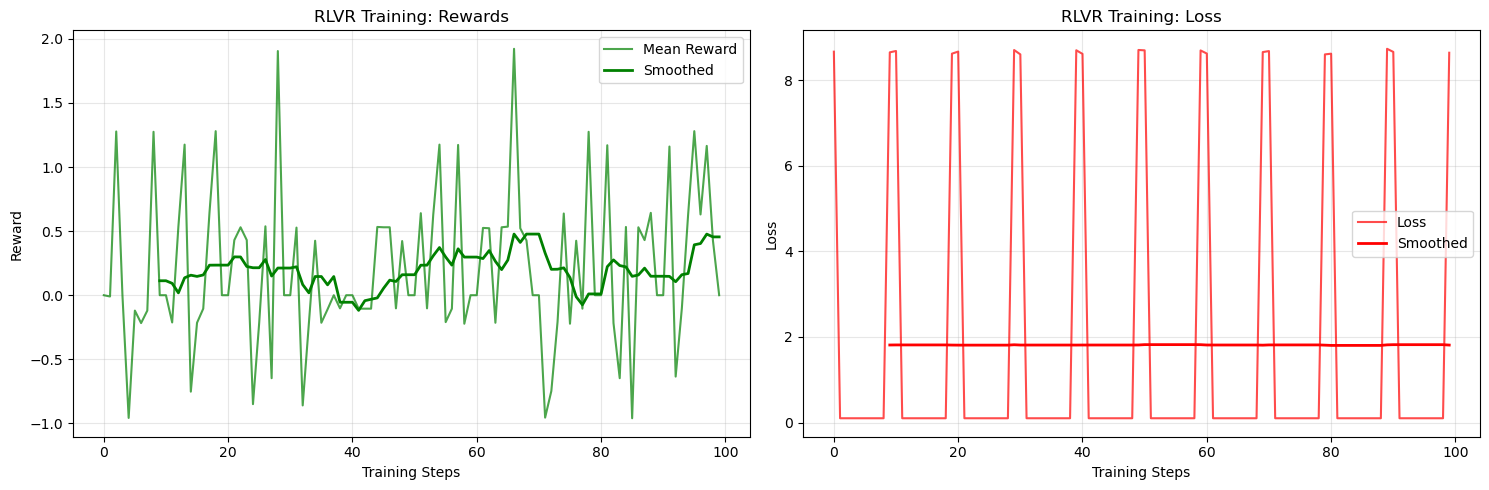

Training Statistics:
  Mean Reward: 0.2597
  Max Reward: 1.9225
  Min Reward: -0.9600
  Mean Loss: 1.8113
  Final Loss: 8.6372


In [7]:
# Plot training metrics
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot rewards
if any(training_metrics["rewards"]):
    axes[0].plot(training_metrics["steps"], training_metrics["rewards"], 
                'g-', alpha=0.7, label='Mean Reward')
    
    # Add smoothed line
    if len(training_metrics["rewards"]) > 10:
        window = 10
        smoothed = np.convolve(training_metrics["rewards"], 
                              np.ones(window)/window, mode='valid')
        axes[0].plot(training_metrics["steps"][window-1:], smoothed, 
                    'g-', linewidth=2, label='Smoothed')
    
    axes[0].set_xlabel('Training Steps')
    axes[0].set_ylabel('Reward')
    axes[0].set_title('RLVR Training: Rewards')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# Plot losses
axes[1].plot(training_metrics["steps"], training_metrics["losses"], 
            'r-', alpha=0.7, label='Loss')

if len(training_metrics["losses"]) > 10:
    window = 10
    smoothed = np.convolve(training_metrics["losses"], 
                          np.ones(window)/window, mode='valid')
    axes[1].plot(training_metrics["steps"][window-1:], smoothed, 
                'r-', linewidth=2, label='Smoothed')

axes[1].set_xlabel('Training Steps')
axes[1].set_ylabel('Loss')
axes[1].set_title('RLVR Training: Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("Training Statistics:")
if any(training_metrics["rewards"]):
    rewards = [r for r in training_metrics["rewards"] if r != 0]
    if rewards:
        print(f"  Mean Reward: {np.mean(rewards):.4f}")
        print(f"  Max Reward: {np.max(rewards):.4f}")
        print(f"  Min Reward: {np.min(rewards):.4f}")

losses = [l for l in training_metrics["losses"] if l != 0]
if losses:
    print(f"  Mean Loss: {np.mean(losses):.4f}")
    print(f"  Final Loss: {losses[-1]:.4f}")

## 8. Test Model Generation with Verification

In [8]:
# Test the model's generation capabilities
print("=" * 60)
print("TESTING MODEL GENERATION WITH VERIFICATION")
print("=" * 60)

# Test different task types
test_tasks = [
    ("sql", "Generate SQL query for: Select all users\nTable: users(id, name, age)\nSQL:"),
    ("python", "Complete the Python function:\ndef multiply(a, b):"),
    ("arithmetic", "Continue the arithmetic sequence: 2, 4, 6, 8,"),
    ("fibonacci", "Continue the Fibonacci sequence: 1, 1, 2, 3, 5,")
]

for task_type, prompt in test_tasks:
    print(f"\n{'='*40}")
    print(f"Task: {task_type.upper()}")
    print(f"Prompt: {prompt}")
    print("-" * 40)
    
    # Tokenize prompt
    input_ids = trainer.data_generator.tokenize(prompt).reshape(1, -1)
    
    # Generate completion (MLX doesn't need no_grad context)
    generated_ids = trainer.data_generator._generate(
        trainer.model, input_ids, max_new_tokens=30
    )
    
    # Decode
    generated_text = trainer.data_generator.decode(generated_ids[0])
    completion = generated_text[len(prompt):] if len(generated_text) > len(prompt) else generated_text
    
    print(f"Generated: {completion}")
    
    # Verify the generation
    context = {}
    if task_type == "sql":
        context = {"schema": schema}  # Use the schema from earlier
    elif task_type == "arithmetic":
        context = {"difference": 2}
    
    reward, verification = trainer.ppo_trainer.reward_computer.compute_reward(
        completion, task_type, context=context
    )
    
    print(f"\nVerification:")
    print(f"  Success: {verification.success}")
    print(f"  Reward: {reward:.4f}")
    print(f"  Feedback: {verification.feedback}")
    
    if verification.error_message:
        print(f"  Error: {verification.error_message}")

TESTING MODEL GENERATION WITH VERIFICATION

Task: SQL
Prompt: Generate SQL query for: Select all users
Table: users(id, name, age)
SQL:
----------------------------------------
Generated: Generate SQL query for: Select all users
Table: users(id, name, age)
SQL:

Verification:
  Success: False
  Reward: -0.6200
  Feedback: SQL execution error: near "Generate": syntax error
  Error: near "Generate": syntax error

Task: PYTHON
Prompt: Complete the Python function:
def multiply(a, b):
----------------------------------------
Generated: Complete the Python function:
def multiply(a, b):

Verification:
  Success: False
  Reward: -1.0700
  Feedback: Syntax error: invalid syntax (<string>, line 1)
  Error: invalid syntax (<string>, line 1)

Task: ARITHMETIC
Prompt: Continue the arithmetic sequence: 2, 4, 6, 8,
----------------------------------------
Generated: Continue the arithmetic sequence: 2, 4, 6, 8,

Verification:
  Success: True
  Reward: 1.9200
  Feedback: Perfect arithmetic sequence w

## 9. Analyze Training and Get Recommendations

In [9]:
# Perform comprehensive training analysis
from training_utils import analyze_rlvr_training

print("=" * 60)
print("TRAINING ANALYSIS AND RECOMMENDATIONS")
print("=" * 60)

# Get analysis
analysis = analyze_rlvr_training(trainer.metrics_tracker)

# Print issues
if analysis["issues"]:
    print("\n⚠️ Issues Detected:")
    for issue in analysis["issues"]:
        print(f"  • {issue}")
else:
    print("\n✅ No major issues detected")

# Print trends
print("\n📈 Metric Trends:")
for metric, trend_info in analysis["trends"].items():
    direction = "↗" if trend_info["direction"] == "increasing" else "↘"
    print(f"  • {metric}: {direction} {trend_info['direction']} (rate: {trend_info['rate']:.4f})")

# Print recommendations
if analysis["recommendations"]:
    print("\n💡 Recommendations:")
    for rec in analysis["recommendations"]:
        print(f"  • {rec}")

# Experience buffer statistics
buffer_stats = trainer.experience_buffer.get_statistics()
if buffer_stats:
    print("\n📊 Experience Buffer Statistics:")
    print(f"  • Size: {buffer_stats.get('size', 0)}")
    print(f"  • Mean Reward: {buffer_stats.get('mean_reward', 0):.4f}")
    print(f"  • Reward Std: {buffer_stats.get('std_reward', 0):.4f}")

# Curriculum progress (if enabled)
if trainer.curriculum_scheduler:
    print("\n🎯 Curriculum Learning:")
    print(f"  • Current Difficulty: {trainer.curriculum_scheduler.current_difficulty:.2f}")
    print(f"  • Steps Completed: {trainer.curriculum_scheduler.current_step}")

TRAINING ANALYSIS AND RECOMMENDATIONS

✅ No major issues detected

📈 Metric Trends:
  • rewards: ↘ decreasing (rate: 0.0000)
  • success_rates: ↘ decreasing (rate: 0.0000)
  • kl_divergences: ↘ decreasing (rate: 0.0000)
  • entropy: ↗ increasing (rate: 0.0000)

💡 Recommendations:
  • Consider reverting to earlier checkpoint
  • Training progress is slow - adjust hyperparameters

🎯 Curriculum Learning:
  • Current Difficulty: 0.10
  • Steps Completed: 0


## 10. Full Training Pipeline (Optional)

In [10]:
# Uncomment to run full training
"""
# Run complete RLVR-LoRA training
print("Starting full RLVR-LoRA training...")
print("This will take some time...")

# Configure for full training
full_config = RLVRLoRAConfig(
    lora_rank=16,
    lora_alpha=32.0,
    sft_steps=1000,
    rlvr_steps=4000,
    hybrid_mode=True,
    hybrid_ratio=0.25
)

# Run training
trained_model, full_trainer = run_rlvr_lora_training(
    model=base_model,
    tokenizer=tokenizer,
    num_steps=5000,
    config=full_config
)

print("\nTraining completed!")
print("Model checkpoints saved to: rlvr_checkpoints/")

# Final evaluation
final_eval = full_trainer.evaluate(num_samples=100)
print("\nFinal Evaluation:")
for metric, value in final_eval.items():
    print(f"  {metric}: {value:.4f}")
"""
print("Full training code is commented out. Uncomment to run complete training.")

Full training code is commented out. Uncomment to run complete training.


## Summary

This notebook demonstrated the **RLVR (Reinforcement Learning from Verifiable Rewards)** approach integrated with **LoRA adapters** for efficient fine-tuning. Key features:

### 🎯 **What We Accomplished:**
- **Verifiable Rewards**: Automatic verification of SQL queries, Python code, and pattern sequences
- **PPO Training**: State-of-the-art RL algorithm for language model optimization
- **Hybrid Training**: Combined supervised fine-tuning with RL optimization
- **LoRA Integration**: Parameter-efficient training with only ~10% trainable parameters
- **Curriculum Learning**: Progressive difficulty adjustment based on performance
- **Experience Replay**: Efficient reuse of generated trajectories

### 📈 **Key Benefits of RLVR:**
- **Correctness**: Models learn to generate verifiably correct outputs
- **Execution Feedback**: Direct feedback from code/SQL execution
- **Adaptive Training**: Automatic adjustment to training plateaus
- **Efficiency**: LoRA reduces memory and computation requirements
- **Flexibility**: Works with various task types and verification methods

### 🚀 **Real-World Applications:**
- **SQL Generation**: Database query generation with execution verification
- **Code Completion**: Programming assistance with test-based validation
- **Mathematical Reasoning**: Problem solving with correctness checking
- **Data Analysis**: Generate and verify data processing pipelines
- **System Commands**: Safe command generation with sandboxed execution

### 💡 **Next Steps:**
1. **Scale Up**: Use larger pre-trained models (LLaMA, CodeLlama)
2. **Real Data**: Train on actual SQL/code datasets
3. **Advanced Verification**: Add more sophisticated verification methods
4. **Multi-Task**: Train on multiple task types simultaneously
5. **Production**: Deploy for real-world code/query generation

The RLVR approach ensures that models not only generate plausible-looking outputs but actually produce **correct, executable solutions** - a crucial requirement for production AI systems.